# Imports

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Conv2d, BatchNorm2d, SiLU, Identity, Module, Sequential
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import math
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# U-Net implementation

In [25]:
class Conv(Sequential):
    def __init__(self, cin, cout, k=3, norm=True, act="silu"):
        super().__init__(
        BatchNorm2d(cin) if norm else Identity(),
        Conv2d(cin, cout, k, padding="same"),
        {"none": Identity(), "silu":SiLU()}[act]
        )
        
class DoubleConv(Sequential):
    def __init__(self, cin, cout, k=3, norm=True, act="silu"):
        super().__init__(
            Conv(cin, cout, k, norm, act),
            Conv(cout, cout, k, norm, act)
        )

In [26]:
class UNET(Module):
    def __init__(self, c):
        super().__init__()
        self.d1 = DoubleConv(2, c)
        self.d2 = DoubleConv(c, c*2)
        self.d3 = DoubleConv(c*2, c*4)
        self.d4 = DoubleConv(c*4, c*8)

        self.bn = DoubleConv(c*8, c*8)

        self.u4 = DoubleConv(c*16, c*4)
        self.u3 = DoubleConv(c*8, c*2)
        self.u2 = DoubleConv(c*4, c)
        self.u1 = DoubleConv(c*2, c)
        self.u0 = DoubleConv(c, 1, act="none")

    def forward(self, x):
        x = F.pad(x, [2,2,2,2])
        x1 = F.max_pool2d(self.d1(x), 2, 2)
        x2 = F.max_pool2d(self.d2(x1), 2, 2)
        x3 = F.max_pool2d(self.d3(x2), 2, 2)
        x4 = F.max_pool2d(self.d4(x3), 2, 2)

        x = self.bn(x4)

        x = F.interpolate(self.u4(torch.cat([x4, x], dim=1)), scale_factor=2)
        x = F.interpolate(self.u3(torch.cat([x3, x], dim=1)), scale_factor=2)
        x = F.interpolate(self.u2(torch.cat([x2, x], dim=1)), scale_factor=2)
        x = F.interpolate(self.u1(torch.cat([x1, x], dim=1)), scale_factor=2)
        x = self.u0(x)
        x = F.pad(x, [-2,-2,-2,-2])
        return x

# MNIST setup

In [27]:
def get_mnist_dataloader(batch_size=256):
    train_dataset = datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=ToTensor()
    )
    train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
    )
    return train_loader

if __name__ == "__main__":
    train_loader = get_mnist_dataloader(batch_size=256)
    
    images, labels = next(iter(train_loader))
    print(f"Feature batch shape: {images.shape}")
    print(f"Labels batch shape: {labels.shape}")

Feature batch shape: torch.Size([256, 1, 28, 28])
Labels batch shape: torch.Size([256])


# Defining model

In [32]:
save_path = "flow-matching-basic.pth"
unet = UNET(64).to(device)
try:
   state_dict = torch.load(save_path, map_location=device) 
   unet.load_state_dict(state_dict)
except:
   pass

optim = torch.optim.Adam(unet.parameters(), fused=True)

# Training

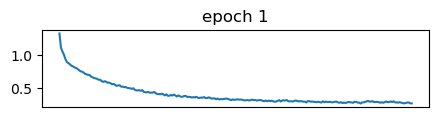

Model successfully saved to flow-matching-basic.pth


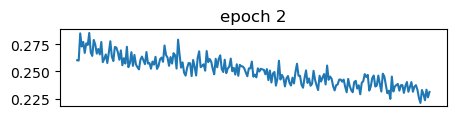

Model successfully saved to flow-matching-basic.pth


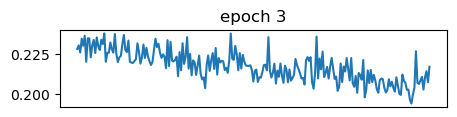

Model successfully saved to flow-matching-basic.pth


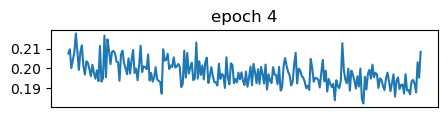

Model successfully saved to flow-matching-basic.pth


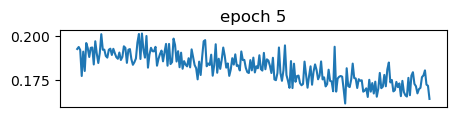

Model successfully saved to flow-matching-basic.pth


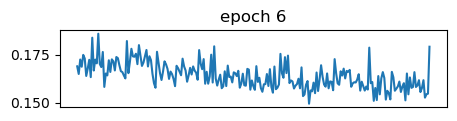

Model successfully saved to flow-matching-basic.pth


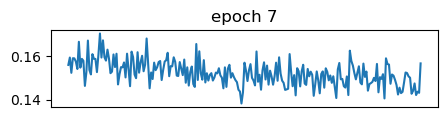

Model successfully saved to flow-matching-basic.pth


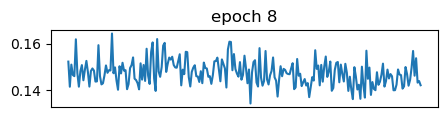

Model successfully saved to flow-matching-basic.pth


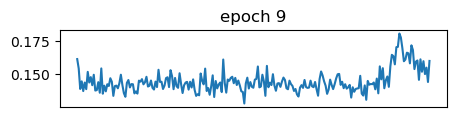

Model successfully saved to flow-matching-basic.pth


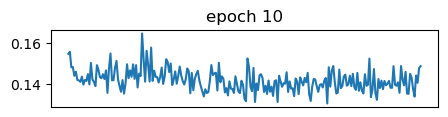

Model successfully saved to flow-matching-basic.pth


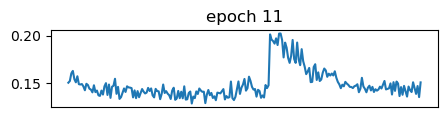

Model successfully saved to flow-matching-basic.pth


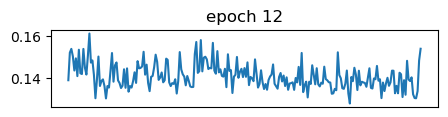

Model successfully saved to flow-matching-basic.pth


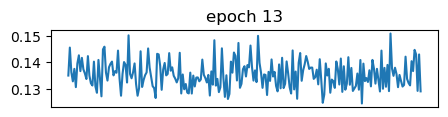

Model successfully saved to flow-matching-basic.pth


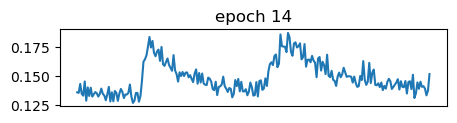

Model successfully saved to flow-matching-basic.pth


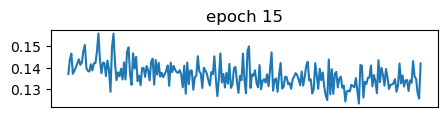

Model successfully saved to flow-matching-basic.pth


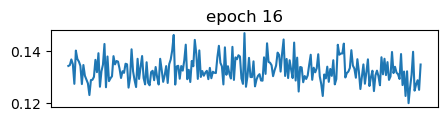

Model successfully saved to flow-matching-basic.pth


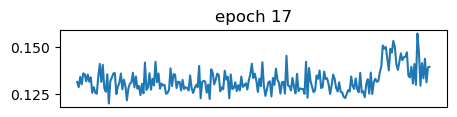

Model successfully saved to flow-matching-basic.pth


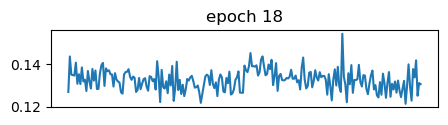

Model successfully saved to flow-matching-basic.pth


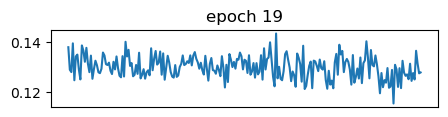

Model successfully saved to flow-matching-basic.pth


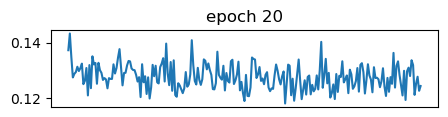

Model successfully saved to flow-matching-basic.pth


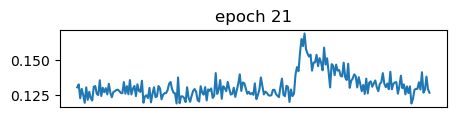

Model successfully saved to flow-matching-basic.pth


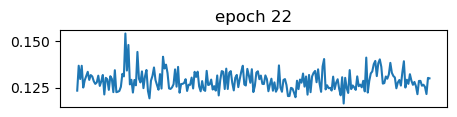

Model successfully saved to flow-matching-basic.pth


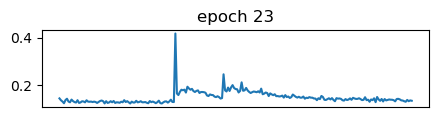

Model successfully saved to flow-matching-basic.pth


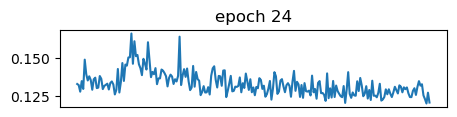

Model successfully saved to flow-matching-basic.pth


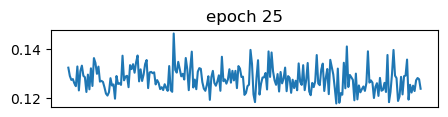

Model successfully saved to flow-matching-basic.pth


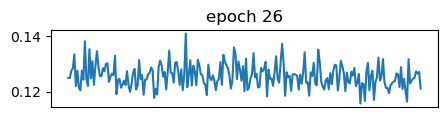

Model successfully saved to flow-matching-basic.pth


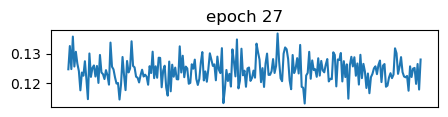

Model successfully saved to flow-matching-basic.pth


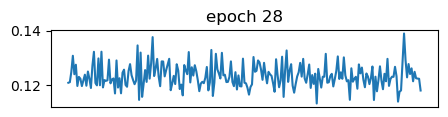

Model successfully saved to flow-matching-basic.pth


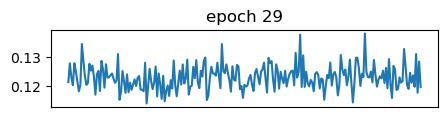

Model successfully saved to flow-matching-basic.pth


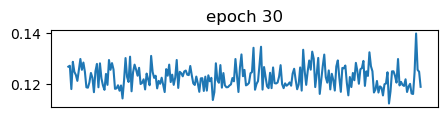

Model successfully saved to flow-matching-basic.pth


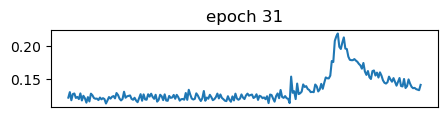

Model successfully saved to flow-matching-basic.pth


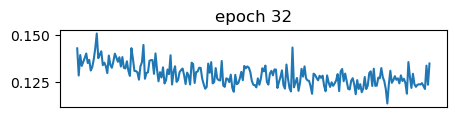

Model successfully saved to flow-matching-basic.pth


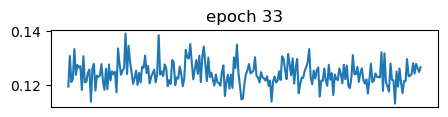

Model successfully saved to flow-matching-basic.pth


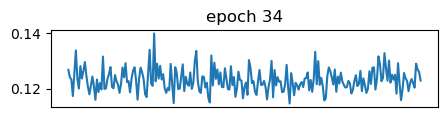

Model successfully saved to flow-matching-basic.pth


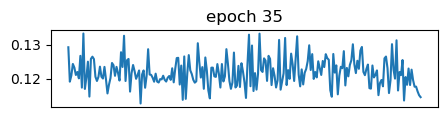

Model successfully saved to flow-matching-basic.pth


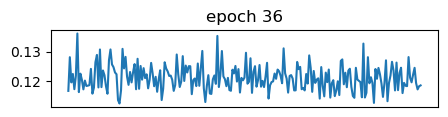

Model successfully saved to flow-matching-basic.pth


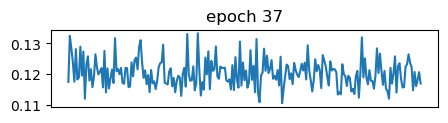

Model successfully saved to flow-matching-basic.pth


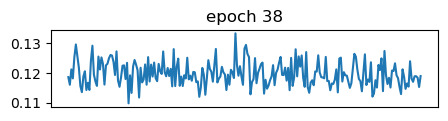

Model successfully saved to flow-matching-basic.pth


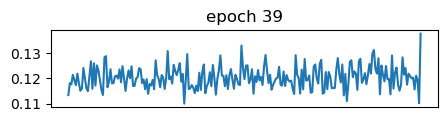

Model successfully saved to flow-matching-basic.pth


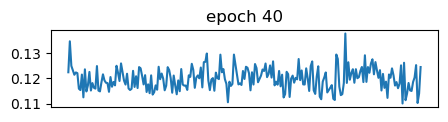

Model successfully saved to flow-matching-basic.pth


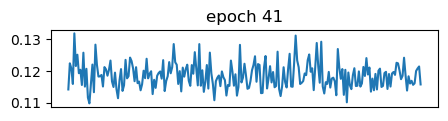

Model successfully saved to flow-matching-basic.pth


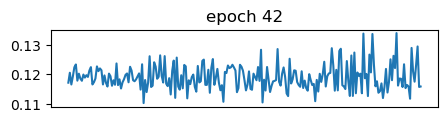

Model successfully saved to flow-matching-basic.pth


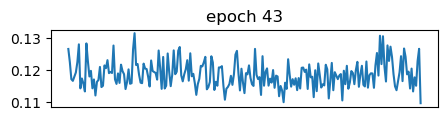

Model successfully saved to flow-matching-basic.pth


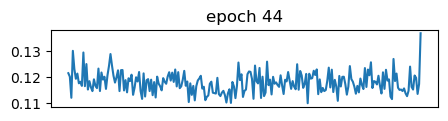

Model successfully saved to flow-matching-basic.pth


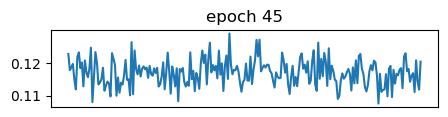

Model successfully saved to flow-matching-basic.pth


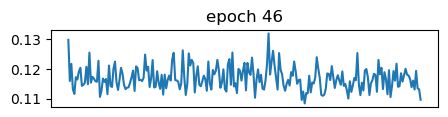

Model successfully saved to flow-matching-basic.pth


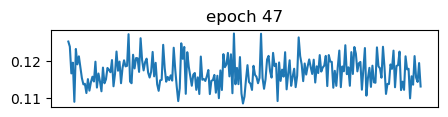

Model successfully saved to flow-matching-basic.pth


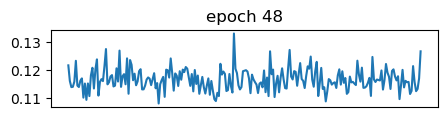

Model successfully saved to flow-matching-basic.pth


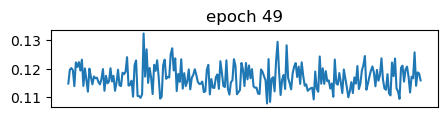

Model successfully saved to flow-matching-basic.pth


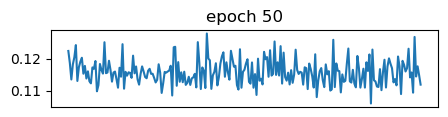

Model successfully saved to flow-matching-basic.pth


In [33]:
def train_epoch(unet, loader, optimizer, epoch):
    unet.train()
    losses = []
    for x, _ in loader:
        x = x.to(device)

        eps = torch.randn_like(x)
        t = torch.rand(len(x), 1, 1, 1, device=device)
        z = x * (1 - t) + eps * t
        y = eps - x
        zt = torch.cat((z, t.repeat(1, 1, 28, 28)), dim=1).to(device)
        y_hat = unet(zt)

        loss = (y - y_hat).pow(2).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(
            unet.parameters(),
            max_norm=1.0,
            foreach=True
        )
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())

    plt.figure(None, (5,1))
    plt.xticks([])
    plt.title(f"epoch {epoch+1}")
    plt.plot(losses)
    plt.show()

    torch.save(unet.state_dict(), save_path)
    print(f"Model successfully saved to {save_path}")

for g in optim.param_groups:
    g['lr'] = 67e-4 / 2 # 67

for epoch in range(50):
    train_epoch(unet, train_loader, optim, epoch)

# Interference

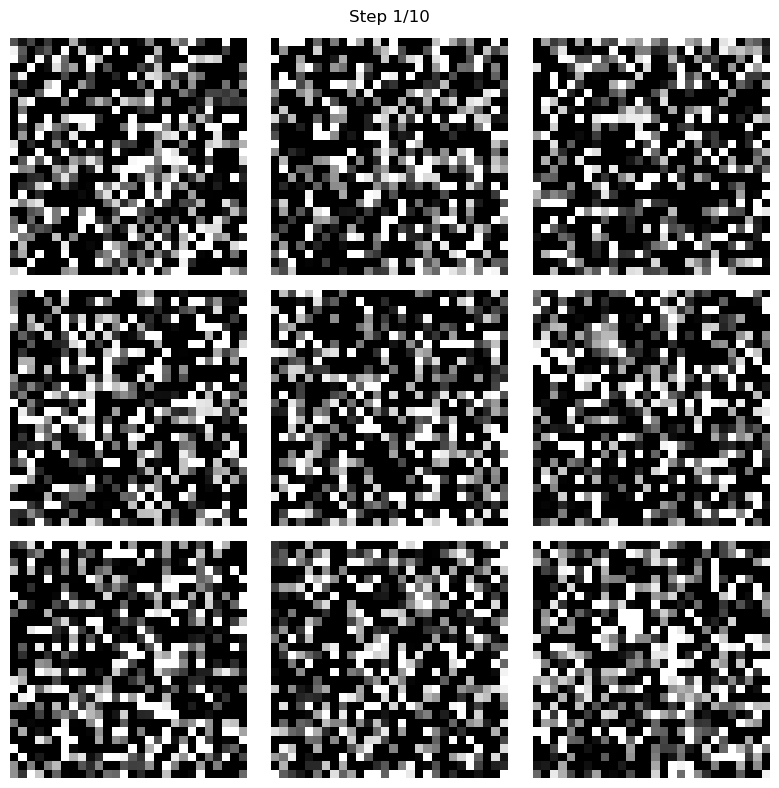

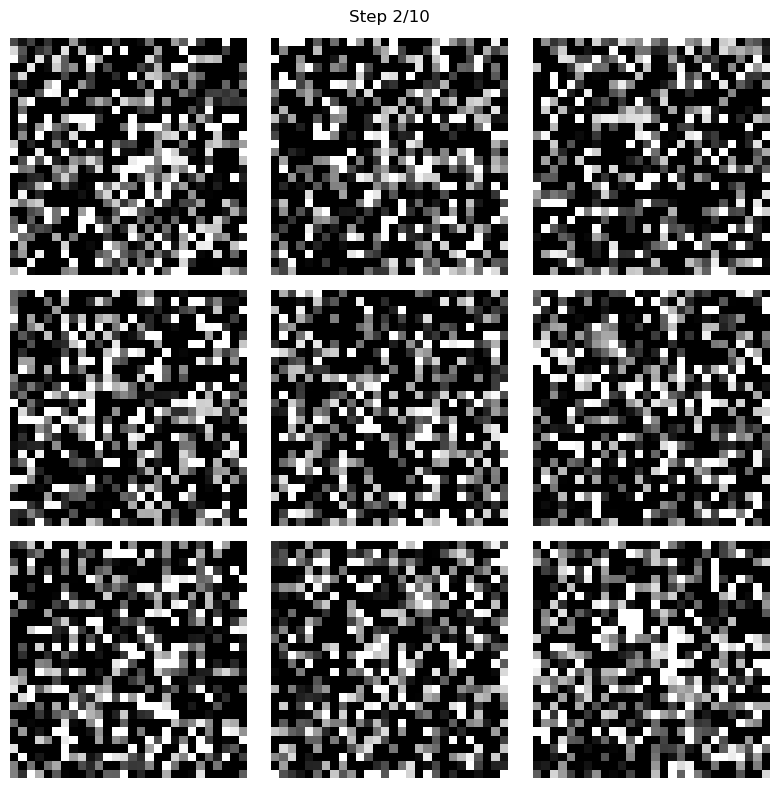

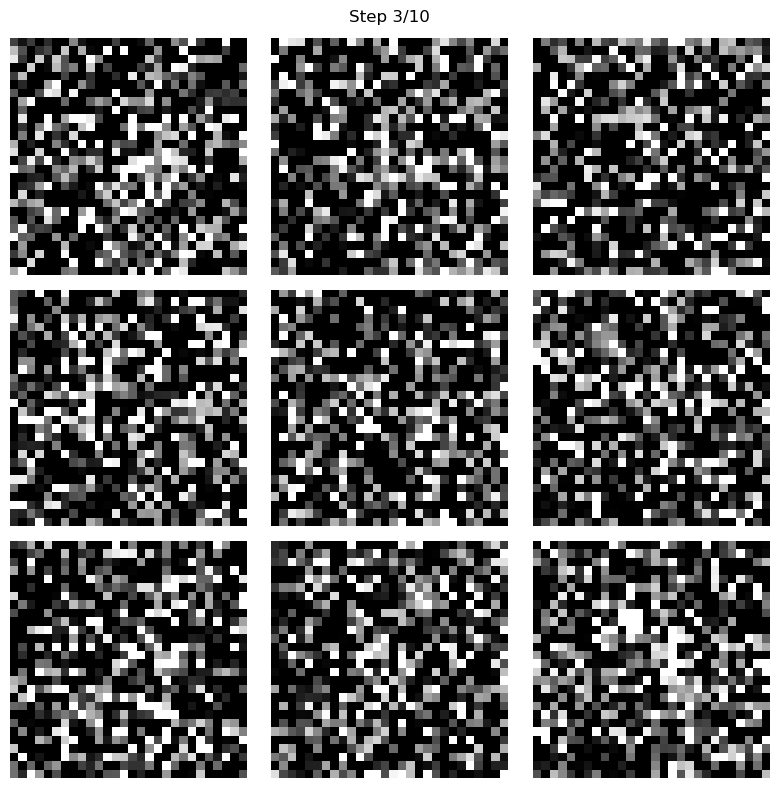

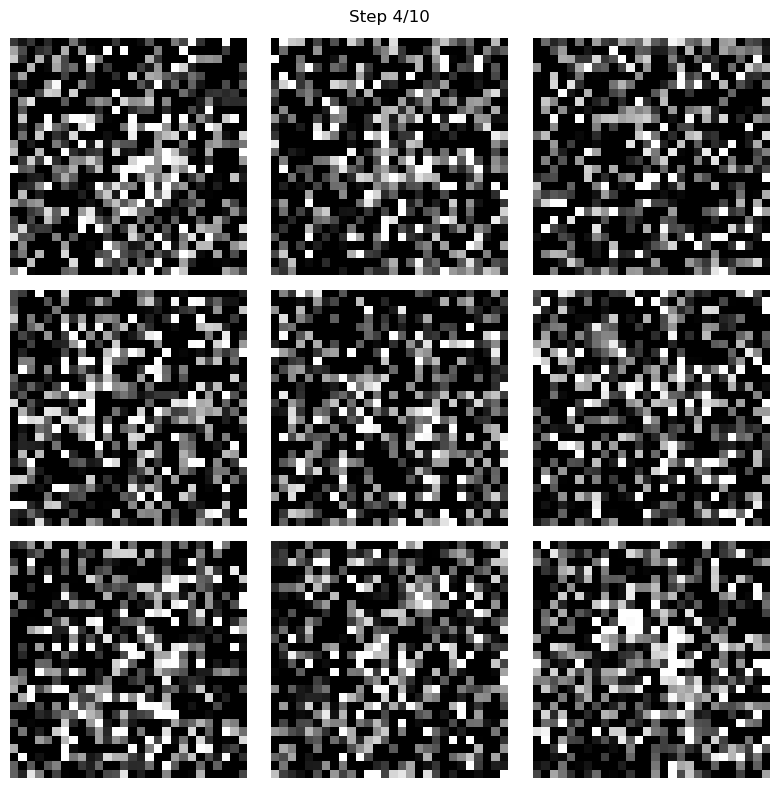

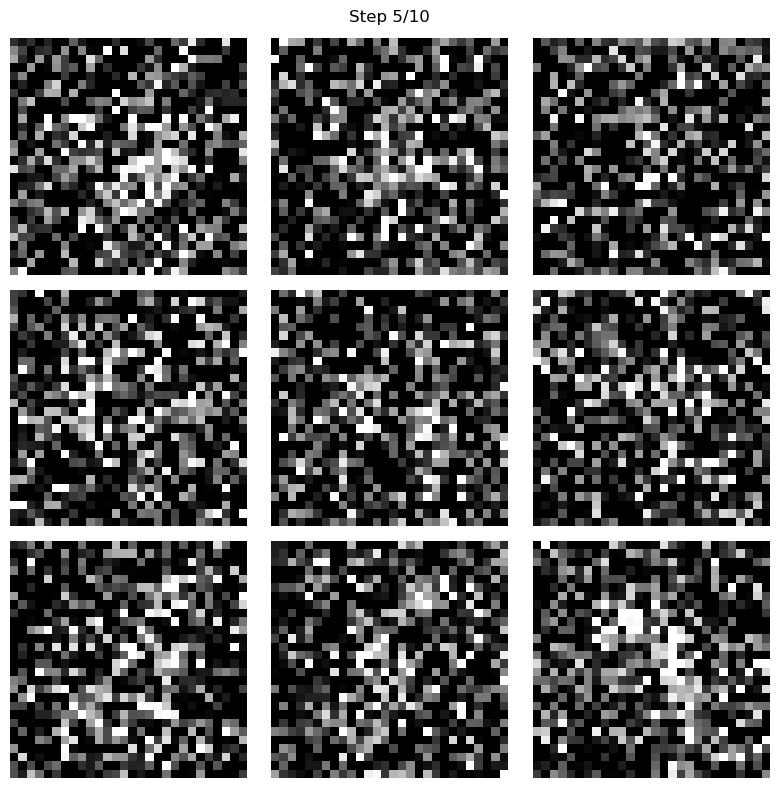

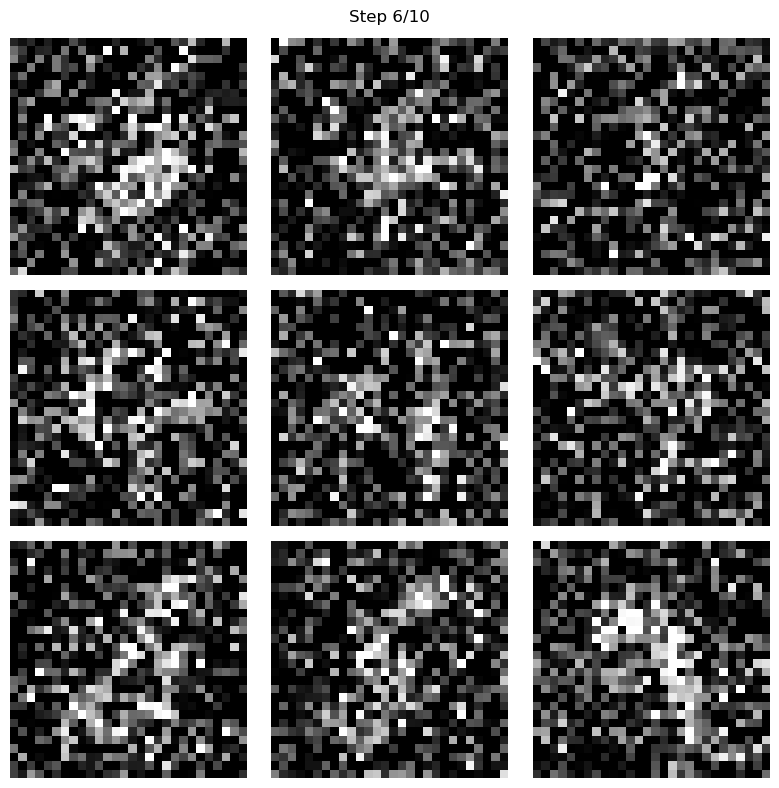

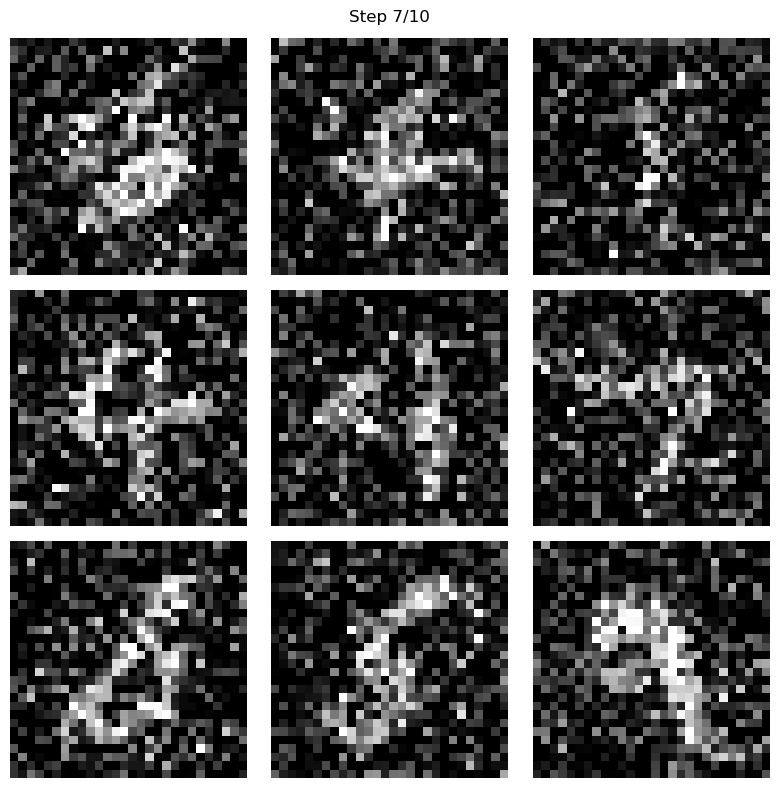

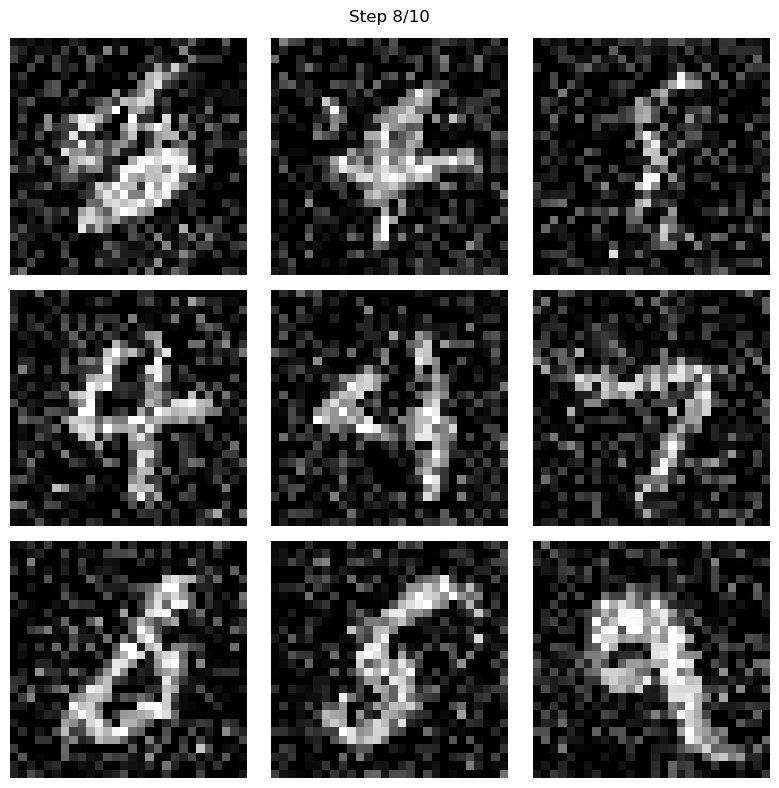

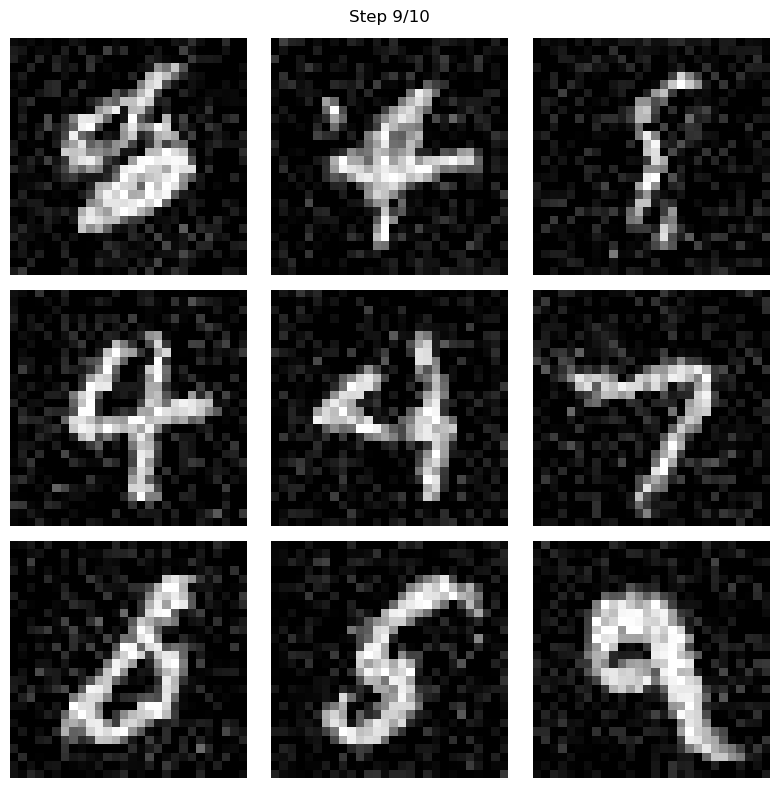

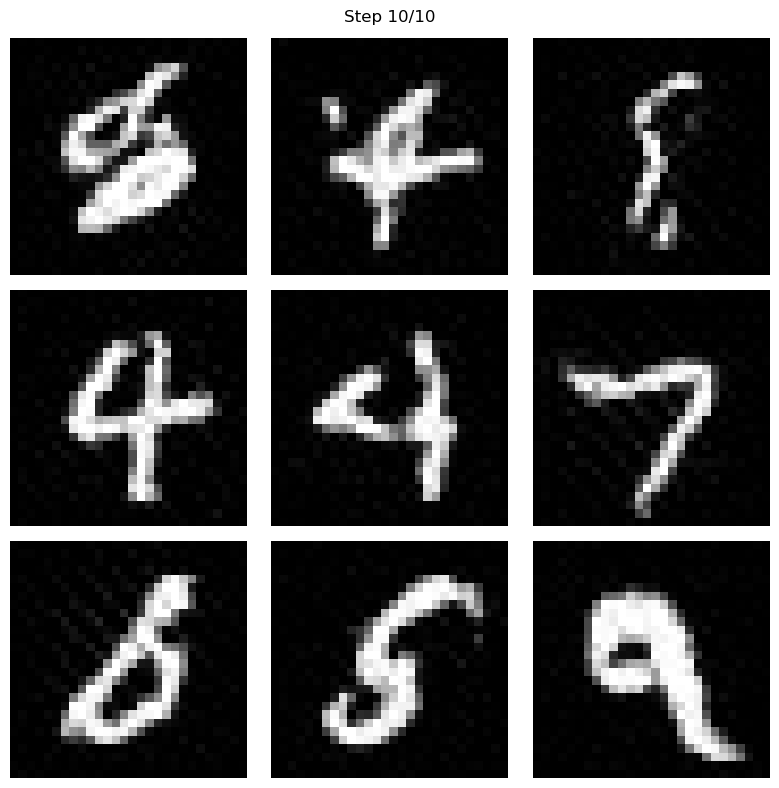

In [35]:
def visualize_results(unet, num_samples=16, steps=20):
    unet.eval()
    x_t = torch.randn((num_samples, 1, 28, 28), device=device)
    ts = torch.linspace(1.0, 0.0, steps + 1, device=device)
    n = int(math.sqrt(num_samples))
    for step_idx, (t_from, t_to) in enumerate(zip(ts[:-1], ts[1:]), start=1):
        t = torch.full((num_samples, 1, 28, 28), t_from, device=device)
        zt = torch.cat((x_t, t), dim=1)

        with torch.no_grad():
            sigma = unet(zt)

        x_t = x_t.detach()

        x_0 = x_t - t_from * sigma
        x_0 = x_0.clamp(0, 1)
        sigma = (x_t - x_0) / t_from
        x_t = x_t + sigma * (t_to - t_from)

        imgs = x_t.detach().cpu().clamp(0, 1)

        fig, axes = plt.subplots(n, n, figsize=(8, 8))
        axes = axes.flatten()

        for i in range(num_samples):
            axes[i].imshow(imgs[i, 0], cmap="gray")
            axes[i].axis("off")

        for i in range(num_samples, len(axes)):
            axes[i].axis("off")

        fig.suptitle(f"Step {step_idx}/{steps}")
        plt.tight_layout()
        plt.show()

    

visualize_results(
    unet,
    num_samples=9,
    steps=10
)